### CASE STUDTY : CUSTOMER INSURANCE PURCHASES (ML COMPARATIVE ANALYSIS)

#### Data Preparation

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

url="https://drive.google.com/file/d/1wOrVrq30W3bl1st4cvnt5bvn5UWEK4Ab/view?usp=drive_link"
gdown.download(url,"insurance.csv",fuzzy=True)
dataset=pd.read_csv("insurance.csv")
print(dataset.head())

Downloading...
From: https://drive.google.com/uc?id=1wOrVrq30W3bl1st4cvnt5bvn5UWEK4Ab
To: C:\Users\Hima\Project\insurance.csv
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.90k/4.90k [00:00<00:00, 8.58MB/s]

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [6]:
X=dataset[['Age','EstimatedSalary']]
y=dataset['Purchased']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

X_train=sc.fit_transform(X_train)
X_test =sc.transform(X_test)

 #### Graphical Analysis of data

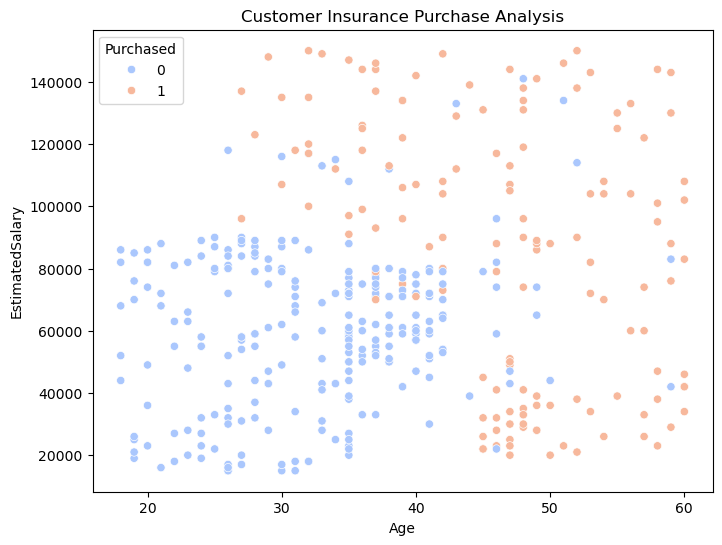

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x=dataset["Age"],
y=dataset["EstimatedSalary"],
hue=dataset["Purchased"],
palette="coolwarm"
)

plt.title("Customer Insurance Purchase Analysis")
plt.show()

### Model Deployment

#### Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

#### KNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

KNeighborsClassifier()

#### SVM

In [11]:
from sklearn.svm import SVC
svm=SVC(kernel='rbf')
svm.fit(X_train,y_train)

SVC()

#### Decision Tree

In [10]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

#### Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

RandomForestClassifier()

### MODEL EVALUATION

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = [lr, knn, svm, dt, rf]

for model in models:
    
    pred = model.predict(X_test)
    
    print("Model:", model.__class__.__name__)
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))
    
    print("-----------------------------")

Model: LogisticRegression
Accuracy : 0.89
Precision: 0.8888888888888888
Recall   : 0.75
F1 Score : 0.8135593220338984
-----------------------------
Model: KNeighborsClassifier
Accuracy : 0.93
Precision: 0.8787878787878788
Recall   : 0.90625
F1 Score : 0.8923076923076924
-----------------------------
Model: SVC
Accuracy : 0.93
Precision: 0.8787878787878788
Recall   : 0.90625
F1 Score : 0.8923076923076924
-----------------------------
Model: DecisionTreeClassifier
Accuracy : 0.9
Precision: 0.8235294117647058
Recall   : 0.875
F1 Score : 0.8484848484848485
-----------------------------
Model: RandomForestClassifier
Accuracy : 0.92
Precision: 0.875
Recall   : 0.875
F1 Score : 0.875
-----------------------------


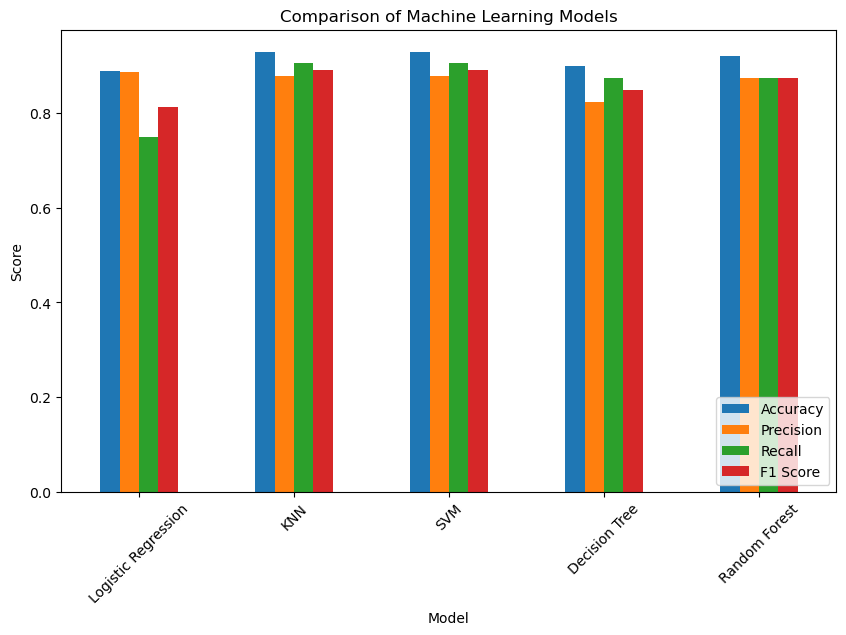

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": [0.89, 0.93, 0.93, 0.90, 0.92],
    "Precision": [0.888, 0.878, 0.878, 0.823, 0.875],
    "Recall": [0.75, 0.906, 0.906, 0.875, 0.875],
    "F1 Score": [0.813, 0.892, 0.892, 0.848, 0.875]
}

df = pd.DataFrame(results)
df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

#### Therefore the best model for this case study is SVM (considering even time complexity and overfitting)

#### Graphical analysis and predictions for given data

In [19]:
test_customers=sc.transform([
    [30,87000],
    [40,0],
    [40,100000],
    [50,0]
])
predictions=svm.predict(test_customers)
print(predictions)

[0 1 1 1]


C:\Users\Hima\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Hima\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


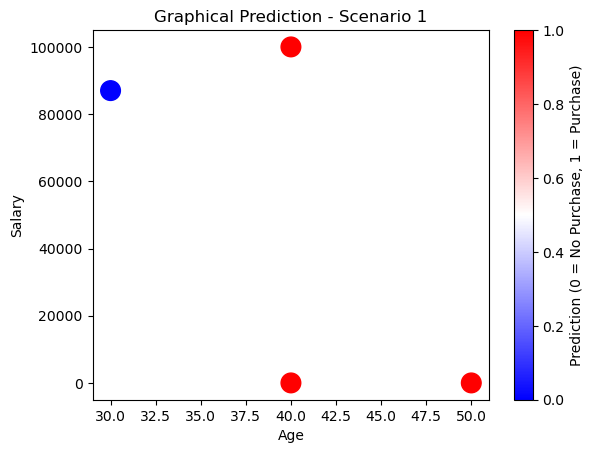

In [23]:
customers1 = np.array([
    [30,87000],
    [40,0],
    [40,100000],
    [50,0]
])

scaled1 = sc.transform(customers1)

pred1 = svm.predict(scaled1)

plt.scatter(customers1[:,0], customers1[:,1], c=pred1, cmap='bwr', s=200)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Graphical Prediction - Scenario 1")
plt.colorbar(label="Prediction (0 = No Purchase, 1 = Purchase)")

plt.show()

In [21]:
test_customers=sc.transform([
    [22,600000],
    [18,0],
    [35,2500000],
    [60,100000000]
])
predictions=svm.predict(test_customers)
print(predictions)

[1 0 1 1]


C:\Users\Hima\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Hima\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


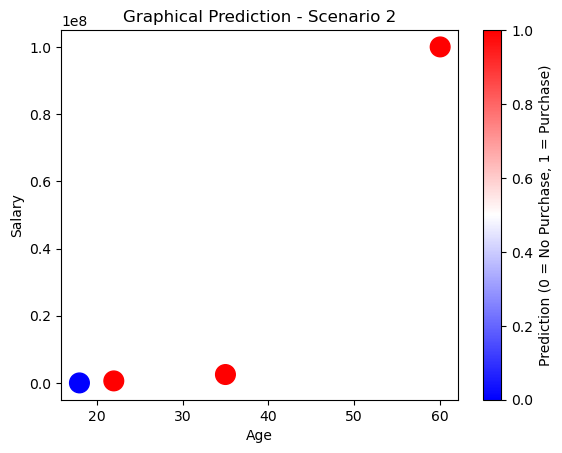

In [24]:
customers2 = np.array([
    [22,600000],
    [18,0],
    [35,2500000],
    [60,100000000]
])

scaled2 = sc.transform(customers2)

pred2 = svm.predict(scaled2)

plt.scatter(customers2[:,0], customers2[:,1], c=pred2, cmap='bwr', s=200)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Graphical Prediction - Scenario 2")
plt.colorbar(label="Prediction (0 = No Purchase, 1 = Purchase)")

plt.show()